## 1. Install & Import Dependencies

In [1]:
!pip install -q tensorflow numpy pandas matplotlib scikit-learn seaborn tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm import tqdm
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import EfficientNetV2B2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D,
    RandomFlip, RandomRotation, RandomZoom,
    RandomBrightness, RandomContrast
)
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint,
    ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPUs               : {[g.name for g in gpus]}')

c:\Users\rupaj\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\rupaj\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (



TensorFlow version : 2.15.1
GPU available      : False


## 2. Configuration

In [3]:
# ── paths ──────────────────────────────────────────────────────────────────
IMAGES_DIR   = './images'
MODEL_DIR    = './saved_models'
LOGS_DIR     = './logs'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOGS_DIR,  exist_ok=True)

# ── image / model settings ─────────────────────────────────────────────────
IMAGE_SIZE   = (260, 260)   # EfficientNetV2B2 native resolution
BATCH_SIZE   = 32
EPOCHS_HEAD  = 15           # train only the new head
EPOCHS_FINE  = 20           # fine-tune top layers
FINE_TUNE_AT = 200          # unfreeze layers after this index

# ── hyperparameters ────────────────────────────────────────────────────────
LR_HEAD      = 1e-3
LR_FINE      = 1e-5
DROPOUT_RATE = 0.4
TEST_SPLIT   = 0.15
VAL_SPLIT    = 0.15

print('Config ready.')

Config ready.


## 3. Load & Explore Dataset

In [4]:
# Collect all jpg files
all_files = sorted(glob.glob(os.path.join(IMAGES_DIR, '*.jpg')))
print(f'Total images found: {len(all_files)}')

# Parse breed name and cat/dog from filename
# Convention: CamelCase = cat, lowercase_with_spaces = dog
records = []
for fp in all_files:
    name   = os.path.basename(fp)
    stem   = os.path.splitext(name)[0]          # e.g. "Abyssinian_34"
    parts  = stem.split('_')
    breed  = ' '.join(parts[:-1])               # drop trailing number
    is_cat = breed[0].isupper()                 # Capital first → cat
    species = 'cat' if is_cat else 'dog'
    records.append({'filepath': fp, 'breed': breed, 'species': species})

df = pd.DataFrame(records)
print(f'Unique breeds  : {df["breed"].nunique()}')
print(f'Cats vs Dogs   :')
print(df['species'].value_counts())
df.head()

Total images found: 7390
Unique breeds  : 37
Cats vs Dogs   :
species
dog    4990
cat    2400
Name: count, dtype: int64


,filepath,breed,species
0,./images\Abyssinian_1.jpg,Abyssinian,cat
1,./images\Abyssinian_10.jpg,Abyssinian,cat
2,./images\Abyssinian_100.jpg,Abyssinian,cat
3,./images\Abyssinian_101.jpg,Abyssinian,cat
4,./images\Abyssinian_102.jpg,Abyssinian,cat


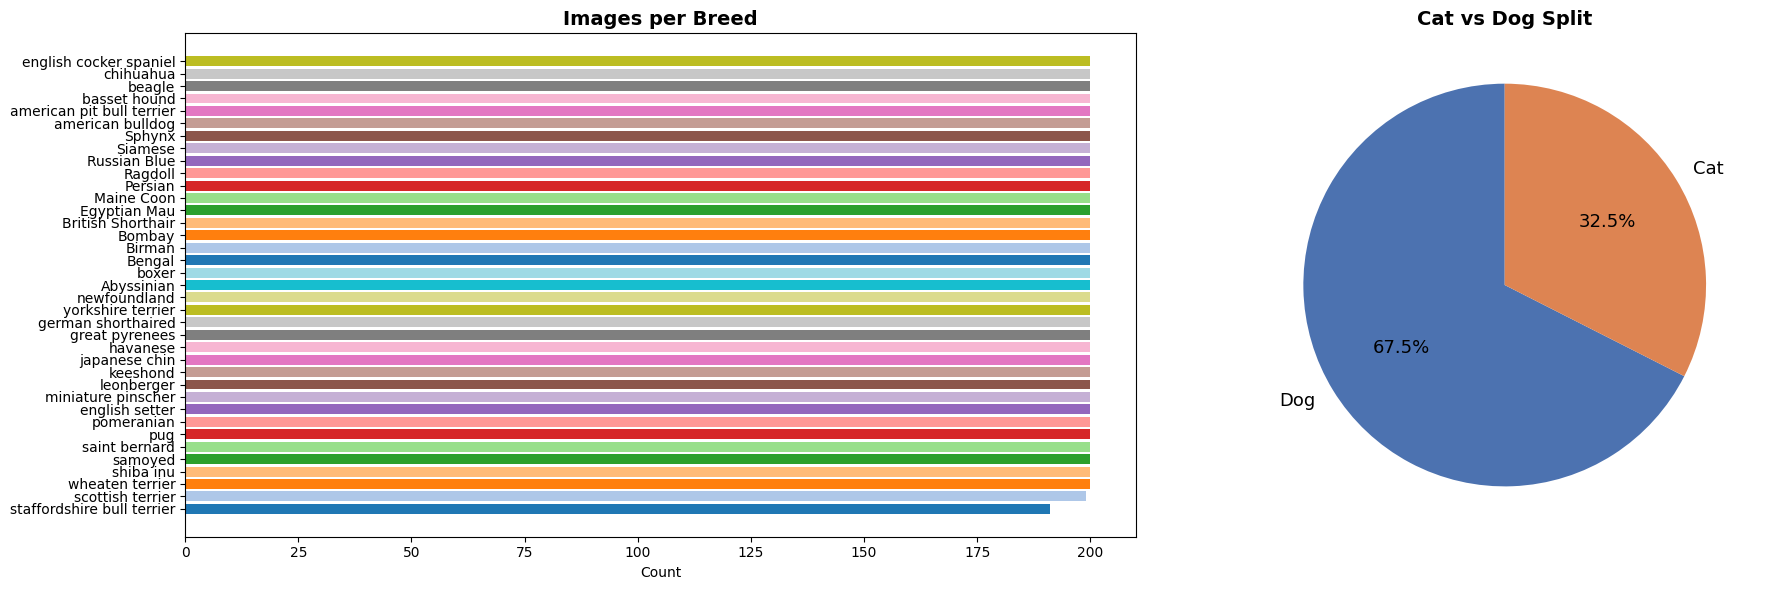

In [5]:
# ── Class distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# breeds
breed_counts = df['breed'].value_counts().sort_values()
axes[0].barh(breed_counts.index, breed_counts.values, color=plt.cm.tab20.colors * 2)
axes[0].set_title('Images per Breed', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count')

# species
axes[1].pie(df['species'].value_counts(), labels=['Dog', 'Cat'],
            autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, textprops={'fontsize': 13})
axes[1].set_title('Cat vs Dog Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'class_distribution.png'), dpi=120)
plt.show()

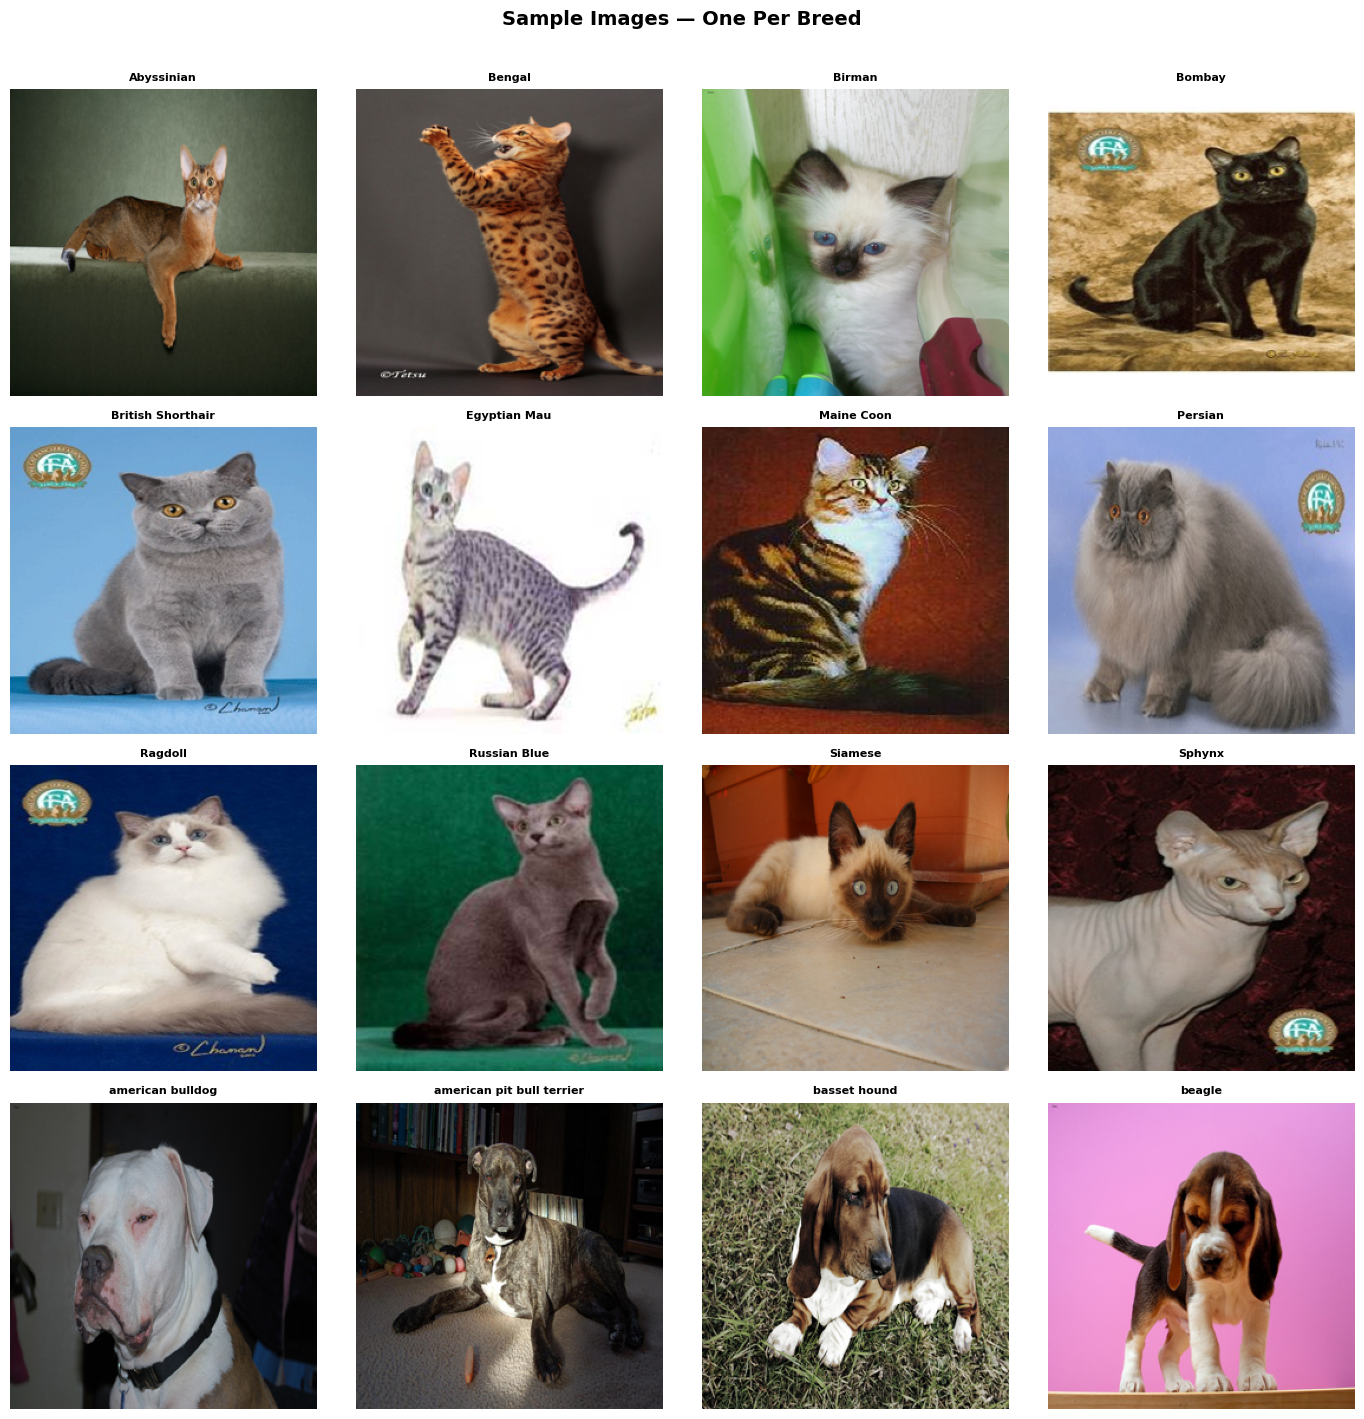

In [6]:
# ── Sample image grid ──────────────────────────────────────────────────────
sample_breeds = df['breed'].unique()[:16]
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, breed in zip(axes.flat, sample_breeds):
    fp = df[df['breed'] == breed].iloc[0]['filepath']
    img = Image.open(fp).resize((260, 260))
    ax.imshow(img)
    ax.set_title(breed, fontsize=8, fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Images — One Per Breed', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'sample_grid.png'), dpi=120, bbox_inches='tight')
plt.show()

## 4. Label Encoding & Train / Val / Test Split

In [7]:
le = LabelEncoder()
df['label_int'] = le.fit_transform(df['breed'])
NUM_CLASSES = df['label_int'].nunique()
print(f'Number of classes: {NUM_CLASSES}')
print('Class mapping (first 10):')
for i, cls in enumerate(le.classes_[:10]):
    print(f'  {i:2d} → {cls}')

Number of classes: 37
Class mapping (first 10):
   0 → Abyssinian
   1 → Bengal
   2 → Birman
   3 → Bombay
   4 → British Shorthair
   5 → Egyptian Mau
   6 → Maine Coon
   7 → Persian
   8 → Ragdoll
   9 → Russian Blue


In [10]:
# Stratified split: train / val / test
# .to_numpy() avoids PyArrow-backed array issues with sklearn
X = df['filepath'].to_numpy(dtype=str)
y = df['label_int'].to_numpy(dtype=int)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y)

val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_ratio, random_state=SEED, stratify=y_train_val)

print(f'Train   : {len(X_train):>5} images')
print(f'Val     : {len(X_val):>5} images')
print(f'Test    : {len(X_test):>5} images')

Train   :  5172 images
Val     :  1109 images
Test    :  1109 images


## 5. Efficient tf.data Pipeline

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(filepath, label):
    """Read image from disk, decode, resize, and one-hot encode label."""
    raw   = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(raw, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def build_dataset(filepaths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# ── Augmentation (applied only on training set) ────────────────────────────
augmentation_layer = Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.15),
    RandomZoom(0.1),
    RandomBrightness(0.2),
    RandomContrast(0.2),
], name='augmentation')

def augment_image(image, label):
    image = augmentation_layer(image, training=True)
    return image, label

train_ds = build_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = build_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = build_dataset(X_test,  y_test,  augment=False, shuffle=False)

print('Datasets built.')
for imgs, lbls in train_ds.take(1):
    print(f'  Batch shape : {imgs.shape},  Labels : {lbls.shape}')


Datasets built.
  Batch shape : (32, 260, 260, 3),  Labels : (32, 37)


## 6. Model — EfficientNetV2B2 + Custom Head

In [12]:
def build_model(num_classes, dropout_rate=DROPOUT_RATE):
    """EfficientNetV2B2 backbone with a classification head."""
    base = EfficientNetV2B2(
        include_top=False,
        weights='imagenet',
        input_shape=(*IMAGE_SIZE, 3),
        include_preprocessing=True   # built-in EfficientNet preprocessing
    )
    base.trainable = False           # freeze backbone initially

    inputs  = Input(shape=(*IMAGE_SIZE, 3))
    x       = base(inputs, training=False)
    x       = GlobalAveragePooling2D()(x)
    x       = Dense(512, activation='relu')(x)
    x       = Dropout(dropout_rate)(x)
    x       = Dense(256, activation='relu')(x)
    x       = Dropout(dropout_rate / 2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='PetBreedClassifier')
    return model, base

model, base_model = build_model(NUM_CLASSES)
model.summary()


35839040/35839040 [==============================] - 22s 1us/step
Model: "PetBreedClassifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 260, 260, 3)]     0         
                                                                 
 efficientnetv2-b2 (Functio  (None, 9, 9, 1408)        8769374   
 nal)                                                            
                                                                 
 global_average_pooling2d (  (None, 1408)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               721408    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                               

## 7. Phase 1 — Train Head (Backbone Frozen)

In [13]:
callbacks_head = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'best_head.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    TensorBoard(log_dir=os.path.join(LOGS_DIR, 'phase1'), histogram_freq=1)
]

model.compile(
    optimizer=Adam(learning_rate=LR_HEAD),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_head
)

print(f'\nBest val accuracy (head): {max(history_head.history["val_accuracy"]):.4f}')

Epoch 1/15


162/162 [==============================] - ETA: 0s - loss: 1.4686 - accuracy: 0.7519 - top5_accuracy: 0.9329
Epoch 1: val_accuracy improved from -inf to 0.91163, saving model to ./saved_models\best_head.keras
162/162 [==============================] - 189s 1s/step - loss: 1.4686 - accuracy: 0.7519 - top5_accuracy: 0.9329 - val_loss: 0.9330 - val_accuracy: 0.9116 - val_top5_accuracy: 0.9964 - lr: 0.0010
Epoch 2/15
 28/162 [====>.........................] - ETA: 1:59 - loss: 1.0813 - accuracy: 0.8761 - top5_accuracy: 0.9911

KeyboardInterrupt: 

## 8. Phase 2 — Fine-tune Top Layers

In [14]:
# Unfreeze the backbone partially
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable backbone layers: {trainable_count} / {len(base_model.layers)}')

callbacks_fine = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, 'best_finetuned.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    TensorBoard(log_dir=os.path.join(LOGS_DIR, 'phase2'), histogram_freq=1)
]

model.compile(
    optimizer=Adam(learning_rate=LR_FINE),   # much lower LR for fine-tuning
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_accuracy')]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks_fine
)

print(f'\nBest val accuracy (fine-tune): {max(history_fine.history["val_accuracy"]):.4f}')

Trainable backbone layers: 149 / 349
Epoch 1/20
162/162 [==============================] - ETA: 0s - loss: 1.0158 - accuracy: 0.9037 - top5_accuracy: 0.9915
Epoch 1: val_accuracy improved from -inf to 0.93598, saving model to ./saved_models\best_finetuned.keras
162/162 [==============================] - 286s 2s/step - loss: 1.0158 - accuracy: 0.9037 - top5_accuracy: 0.9915 - val_loss: 0.8947 - val_accuracy: 0.9360 - val_top5_accuracy: 0.9982 - lr: 1.0000e-05
Epoch 2/20
162/162 [==============================] - ETA: 0s - loss: 0.9780 - accuracy: 0.9142 - top5_accuracy: 0.9942
Epoch 2: val_accuracy improved from 0.93598 to 0.94409, saving model to ./saved_models\best_finetuned.keras
162/162 [==============================] - 1171s 7s/step - loss: 0.9780 - accuracy: 0.9142 - top5_accuracy: 0.9942 - val_loss: 0.8841 - val_accuracy: 0.9441 - val_top5_accuracy: 0.9982 - lr: 1.0000e-05
Epoch 3/20
162/162 [==============================] - ETA: 0s - loss: 0.9594 - accuracy: 0.9240 - top5_accu

KeyboardInterrupt: 

## 9. Training Curves

In [15]:
def merge_history(h1, h2):
    """Concatenate two Keras History objects."""
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return merged

hist = merge_history(history_head, history_fine)
total_epochs = len(hist['accuracy'])
fine_start   = len(history_head.history['accuracy'])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metric, title in zip(
    axes,
    ['accuracy', 'top5_accuracy', 'loss'],
    ['Top-1 Accuracy', 'Top-5 Accuracy', 'Loss']
):
    ax.plot(hist[metric],     label=f'Train',      linewidth=2)
    ax.plot(hist[f'val_{metric}'], label='Validation', linewidth=2, linestyle='--')
    ax.axvline(fine_start, color='red', linestyle=':', linewidth=1.5, label='Fine-tune start')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History — Phase 1 + Fine-tune', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'training_curves.png'), dpi=120)
plt.show()

NameError: name 'history_head' is not defined

## 10. Test Set Evaluation

In [16]:
test_loss, test_acc, test_top5 = model.evaluate(test_ds, verbose=1)
print(f'\n🏆 Test Top-1 Accuracy : {test_acc*100:.2f}%')
print(f'🏆 Test Top-5 Accuracy : {test_top5*100:.2f}%')
print(f'📉 Test Loss           : {test_loss:.4f}')

35/35 [==============================] - 37s 1s/step - loss: 0.8552 - accuracy: 0.9477 - top5_accuracy: 0.9982

🏆 Test Top-1 Accuracy : 94.77%
🏆 Test Top-5 Accuracy : 99.82%
📉 Test Loss           : 0.8552


In [17]:
# Gather predictions for all test images
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred_int   = np.argmax(y_pred_probs, axis=1)
y_true_int   = y_test

print('\n📋 Classification Report:\n')
print(classification_report(y_true_int, y_pred_int, target_names=le.classes_))

35/35 [==============================] - 43s 1s/step

📋 Classification Report:

                            precision    recall  f1-score   support

                Abyssinian       1.00      0.97      0.98        30
                    Bengal       0.93      0.87      0.90        30
                    Birman       0.83      0.97      0.89        30
                    Bombay       0.97      1.00      0.98        30
         British Shorthair       0.93      0.87      0.90        30
              Egyptian Mau       0.93      0.90      0.92        30
                Maine Coon       0.91      0.97      0.94        30
                   Persian       0.97      1.00      0.98        30
                   Ragdoll       0.96      0.80      0.87        30
              Russian Blue       0.93      0.93      0.93        30
                   Siamese       0.97      1.00      0.98        30
                    Sphynx       1.00      1.00      1.00        30
          american bulldog       0.

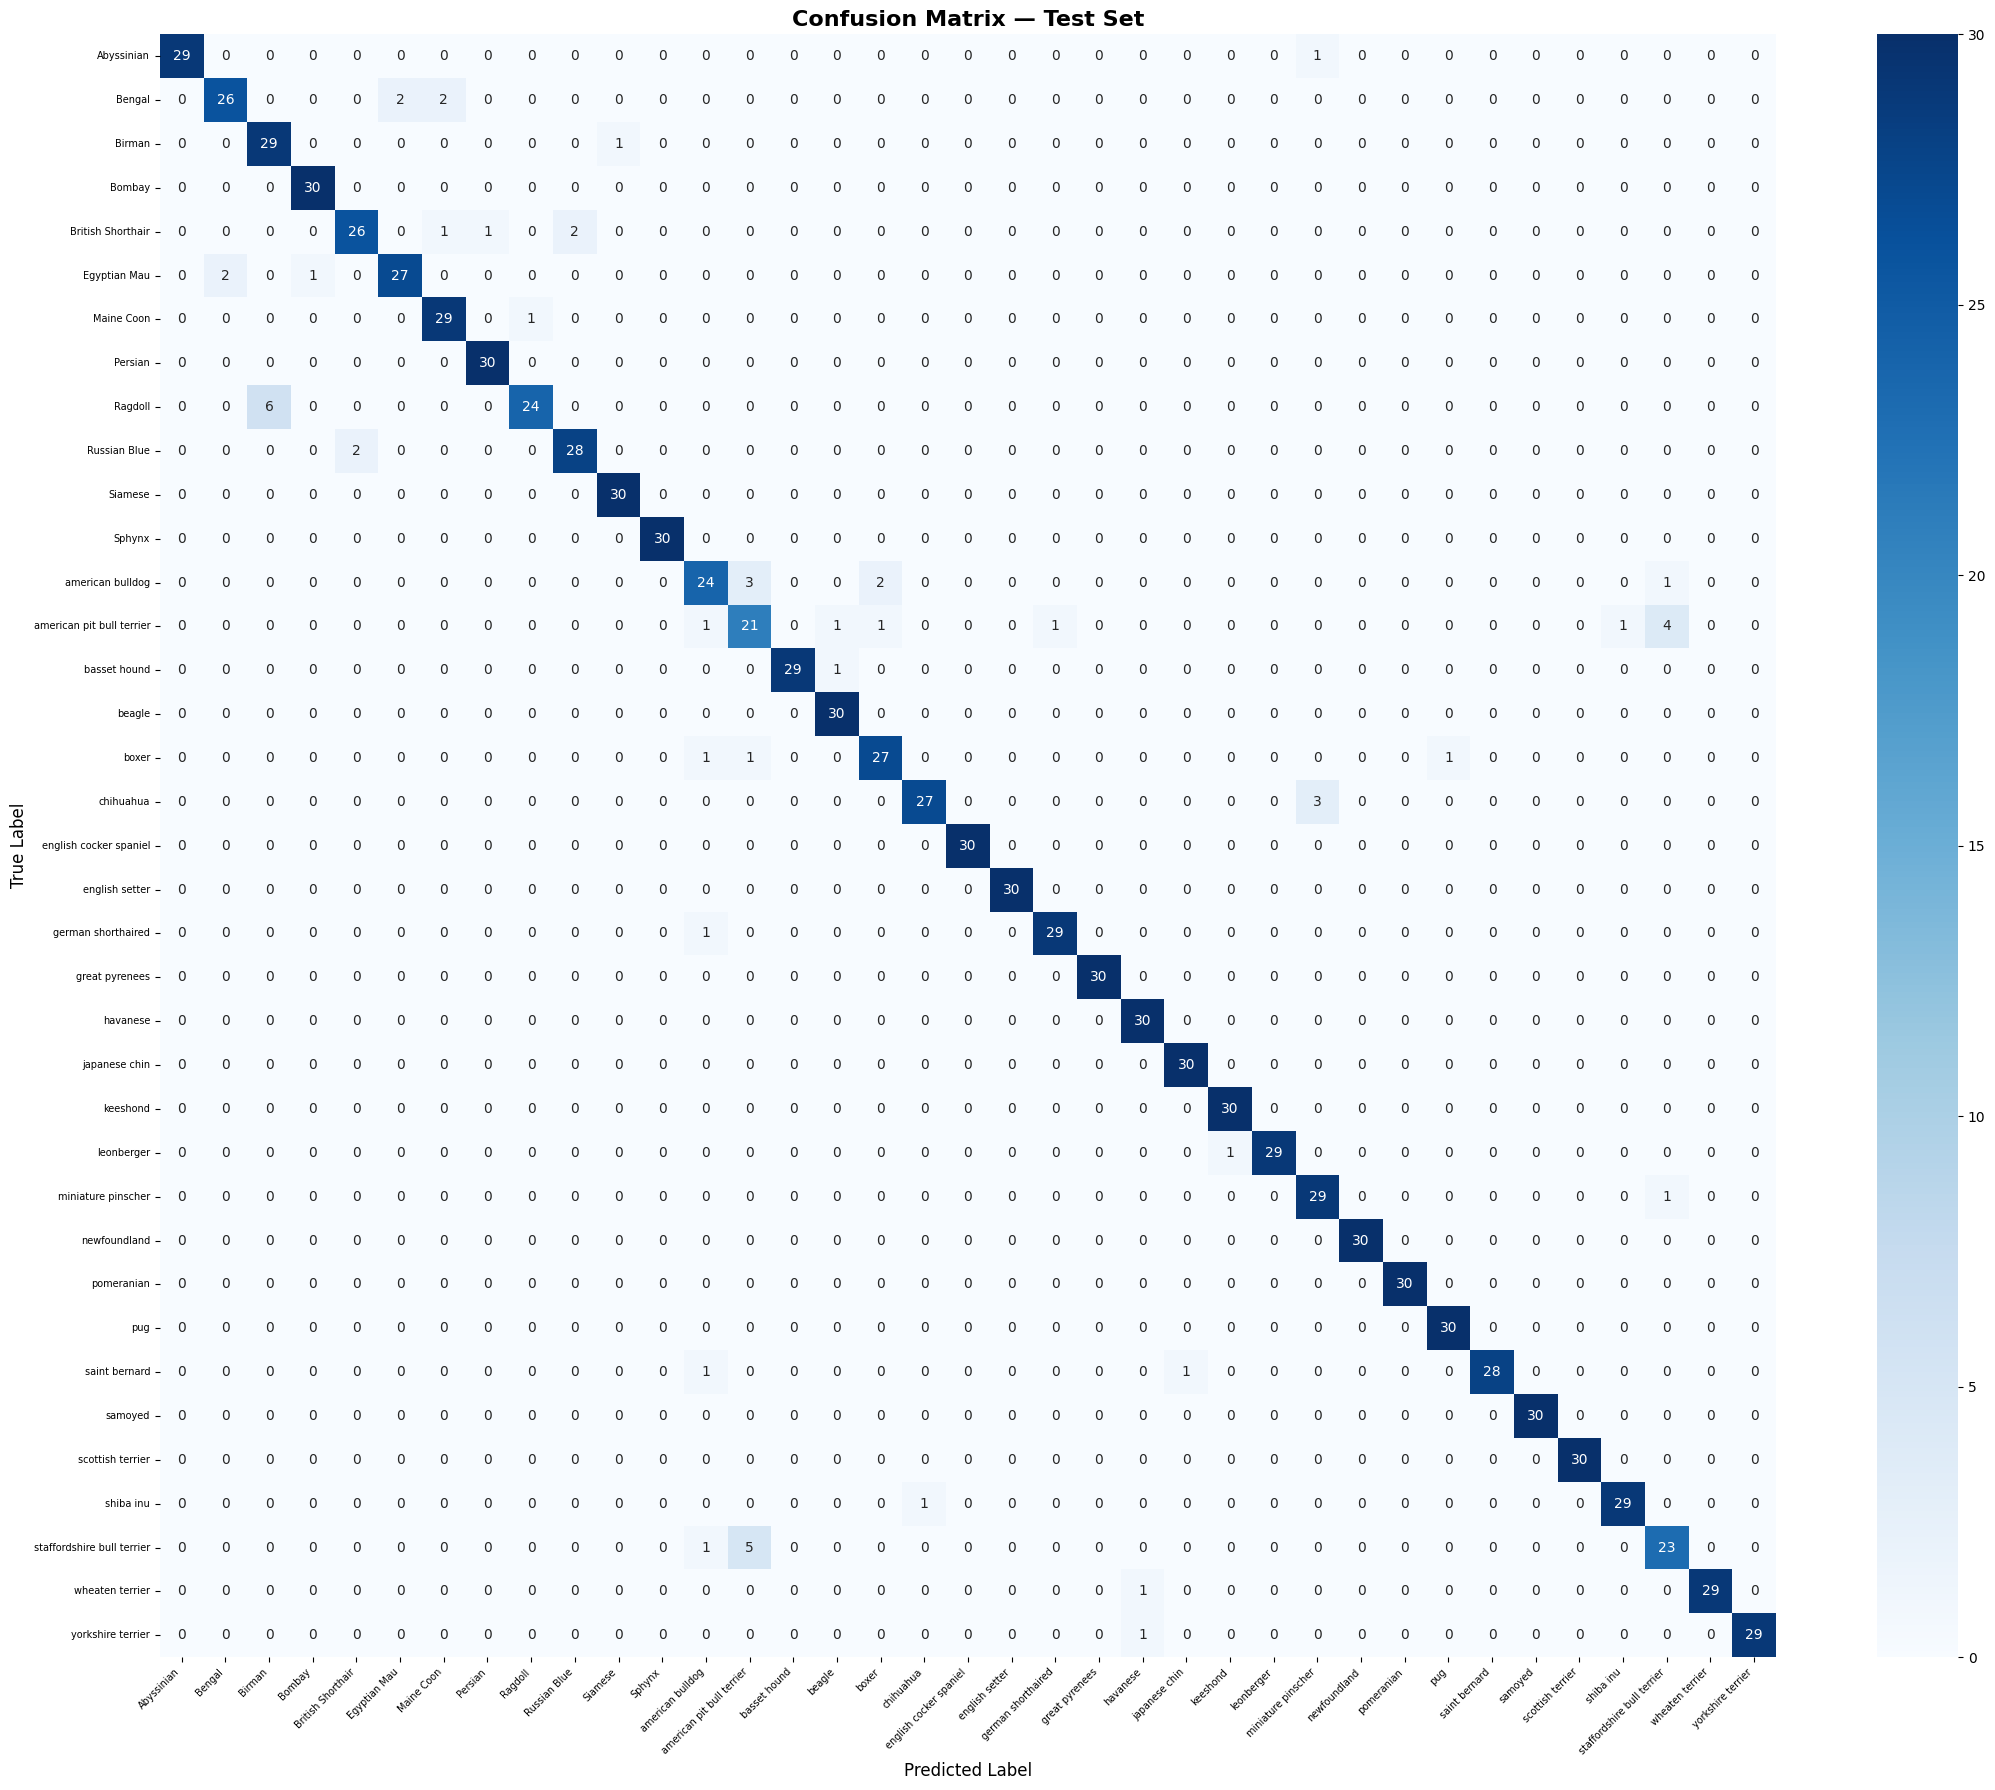

In [18]:
# ── Confusion matrix ───────────────────────────────────────────────────────
cm_arr = confusion_matrix(y_true_int, y_pred_int)

plt.figure(figsize=(22, 18))
sns.heatmap(
    cm_arr,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.title('Confusion Matrix — Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()

## 11. Grad-CAM — Visualise What the Model Sees

In [19]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap for the given image."""
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads      = tape.gradient(class_channel, conv_outputs)
    pooled     = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out   = conv_outputs[0]
    heatmap    = conv_out @ pooled[..., tf.newaxis]
    heatmap    = tf.squeeze(heatmap)
    heatmap    = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(orig_img_path, heatmap, alpha=0.4):
    """Overlay heatmap on the original image."""
    img     = np.array(Image.open(orig_img_path).resize(IMAGE_SIZE))
    heatmap = np.uint8(255 * heatmap)
    jet     = cm.get_cmap('jet')
    colored = jet(np.arange(256))[:, :3]
    colored_heatmap = colored[heatmap]
    colored_heatmap = np.uint8(colored_heatmap * 255)
    colored_heatmap = Image.fromarray(colored_heatmap).resize(IMAGE_SIZE)
    colored_heatmap = np.array(colored_heatmap)
    superimposed    = colored_heatmap * alpha + img * (1 - alpha)
    return np.uint8(superimposed)

# Find the last conv layer name in EfficientNetV2B2
last_conv = next(
    l.name for l in reversed(model.layers)
    if isinstance(l, tf.keras.layers.Conv2D)
    or 'conv' in l.name.lower()
)
# EfficientNetV2B2 last conv is inside the base — get it explicitly
try:
    last_conv = next(
        l.name for l in reversed(base_model.layers)
        if 'conv' in l.name.lower() and len(l.output_shape) == 4
    )
    gradcam_model = Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(last_conv).output, model.output]
    )
    print(f'Using conv layer: {last_conv}')
except Exception as e:
    print(f'Grad-CAM layer search: {e}')

StopIteration: 

In [ ]:
# ── Plot Grad-CAM for 8 random test images ─────────────────────────────────
n_show   = 8
indices  = np.random.choice(len(X_test), n_show, replace=False)

fig, axes = plt.subplots(n_show, 3, figsize=(14, n_show * 4))
fig.suptitle('Grad-CAM Visualisation', fontsize=16, fontweight='bold')

for row, idx in enumerate(indices):
    fp         = X_test[idx]
    true_label = le.classes_[y_true_int[idx]]
    pred_label = le.classes_[y_pred_int[idx]]
    conf       = y_pred_probs[idx][y_pred_int[idx]]

    # Load & preprocess for model
    img_raw  = np.array(Image.open(fp).resize(IMAGE_SIZE))
    img_arr  = np.expand_dims(img_raw.astype('float32'), 0)

    # Grad-CAM
    try:
        hm   = get_gradcam_heatmap(model, img_arr, last_conv)
        cam  = overlay_gradcam(fp, hm)
    except Exception:
        cam  = img_raw
        hm   = np.zeros(IMAGE_SIZE)

    color = 'green' if true_label == pred_label else 'red'

    axes[row, 0].imshow(img_raw)
    axes[row, 0].set_title(f'True: {true_label}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(hm, cmap='jet')
    axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(cam)
    axes[row, 2].set_title(f'Pred: {pred_label} ({conf*100:.1f}%)', fontsize=9, color=color)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(LOGS_DIR, 'gradcam.png'), dpi=100, bbox_inches='tight')
plt.show()

## 12. Top Confident & Worst Predictions

In [ ]:
correct_mask  = (y_pred_int == y_true_int)
incorrect_mask = ~correct_mask

# Top-5 most confident correct
correct_conf = y_pred_probs[correct_mask].max(axis=1)
top_correct  = np.where(correct_mask)[0][np.argsort(-correct_conf)[:5]]

# Top-5 most confident wrong
wrong_conf  = y_pred_probs[incorrect_mask].max(axis=1)
top_wrong   = np.where(incorrect_mask)[0][np.argsort(-wrong_conf)[:5]]

def show_predictions(indices, title):
    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for ax, idx in zip(axes, indices):
        img   = np.array(Image.open(X_test[idx]).resize((260, 260)))
        true  = le.classes_[y_true_int[idx]]
        pred  = le.classes_[y_pred_int[idx]]
        conf  = y_pred_probs[idx][y_pred_int[idx]]
        color = 'green' if true == pred else 'red'
        ax.imshow(img)
        ax.set_title(f'T: {true}\nP: {pred}\n{conf*100:.1f}%', fontsize=8, color=color)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(top_correct, '✅ Most Confident — Correct Predictions')
show_predictions(top_wrong,   '❌ Most Confident — Wrong Predictions')

## 13. Single Image Inference Utility

In [ ]:
def predict_image(image_path, top_k=5):
    """
    Predict the breed of a single pet image.
    
    Args:
        image_path : path to any jpg/png image
        top_k      : return top-k predictions
    Returns:
        dict with top-k breeds and probabilities
    """
    img = np.array(Image.open(image_path).convert('RGB').resize(IMAGE_SIZE)).astype('float32')
    img = np.expand_dims(img, 0)
    probs      = model.predict(img, verbose=0)[0]
    top_idx    = np.argsort(probs)[::-1][:top_k]
    results    = {le.classes_[i]: float(probs[i]) for i in top_idx}

    # Plot
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4))
    ax_img.imshow(np.array(Image.open(image_path).resize(IMAGE_SIZE)))
    ax_img.axis('off')
    ax_img.set_title('Input Image', fontsize=11)

    breeds = list(results.keys())
    confs  = list(results.values())
    colors = ['#2196F3' if i > 0 else '#4CAF50' for i in range(len(breeds))]
    ax_bar.barh(breeds[::-1], confs[::-1], color=colors[::-1])
    ax_bar.set_xlabel('Confidence')
    ax_bar.set_title(f'Top-{top_k} Predictions', fontsize=11)
    ax_bar.set_xlim(0, 1)
    for i, (b, c) in enumerate(zip(breeds[::-1], confs[::-1])):
        ax_bar.text(c + 0.01, i, f'{c*100:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()
    return results

# ── Demo: pick a random test image ─────────────────────────────────────────
demo_img = X_test[np.random.randint(len(X_test))]
print(f'Demo image: {demo_img}')
result = predict_image(demo_img)
print('\nTop-5 predictions:')
for breed, conf in result.items():
    print(f'  {breed:35s}: {conf*100:.2f}%')

## 14. Export — SavedModel + TFLite

In [ ]:
# ── SavedModel ─────────────────────────────────────────────────────────────
saved_path = os.path.join(MODEL_DIR, 'pet_breed_classifier')
model.save(saved_path)
print(f'SavedModel exported → {saved_path}')

# ── TFLite (float32) ───────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_saved_model(saved_path)
tflite_model = converter.convert()
tflite_path  = os.path.join(MODEL_DIR, 'pet_breed_classifier.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f'TFLite model exported → {tflite_path}')
print(f'TFLite size: {os.path.getsize(tflite_path) / 1024 / 1024:.1f} MB')

# ── Save class labels ──────────────────────────────────────────────────────
labels_path = os.path.join(MODEL_DIR, 'class_labels.txt')
with open(labels_path, 'w') as f:
    f.write('\n'.join(le.classes_))
print(f'Class labels saved  → {labels_path}')

## 15. Summary

| Metric | Value |
|--------|-------|
| Backbone | EfficientNetV2B2 (ImageNet) |
| Classes | 37 pet breeds |
| Input size | 260 × 260 |
| Augmentations | Flip, Rotation, Zoom, Brightness, Contrast |
| Loss | Categorical Cross-Entropy + Label Smoothing |
| Metrics | Top-1, Top-5 Accuracy |
| Fine-tuning | Top layers of EfficientNetV2B2 |
| Exports | SavedModel, TFLite |